# Control Template for AFL Users

**Experiment Information:**
- Name: 
- Date: 
- Description (brief): 


## Overview

This notebook provides a template for setting up and running automated experiments using the AFL (Automated Formulation Laboratory) system. The workflow includes:

1. **System Setup**: Connect to AFL services (Robot OT2, Orchestrator, Agent, etc.)
2. **Component Definition**: Specify chemical components via web interface
3. **Stock Solutions**: Define available stock solutions on the pipettor deck
4. **Target Solutions**: Create a grid of target solution compositions
5. **Mass Balance**: Verify which targets can be prepared with available stocks
6. **Measurement Campaign**: Configure and execute sample preparation and measurement
7. **Active Learning**: Optionally enable automated sample selection

---

## System Setup

The following cell attempts to create client connections to the various AFL systems. Read the output text carefully to determine which connections were successful and note the variable names assigned to each client object (e.g., `robot_client`, `orch_client`, `agent_client`).

In [ ]:
%run afl_notebook_setup.ipy

Set up AFL client for Robot OT2 under variable robot_client
Set up AFL client for Orchestrator under variable orch_client



Set up AFL client for AFL Agent under variable agent_client



Attempting to connect to the AFL tiled server...


# Define Components

**Important**: This step must be completed in the web interface before proceeding.

1. Navigate to the OT2 Server web address or use the AFL-Andon app
2. In the left sidebar (scroll down if needed), locate the **"Configure Components"** button
3. Use this interface to specify all chemical components that will be used in this study

**Key considerations:**
- Components that occupy volume (solvents, liquids) **must** have a density specified
- Components without a density will be treated as volume-less solutes (e.g., salts, powders)
- Component names should match exactly what you use in stock and target definitions below 

# Define Stock Solutions

In this section, we define the stock solutions available on the OT2 pipettor deck. Each stock solution requires:
- **Name**: A unique identifier for the stock
- **Composition**: Specified using masses, volumes, concentrations, mass fractions, or volume fractions
- **Location**: Deck position (e.g., '1A1', '1A2') where the stock is physically located

**Usage Pattern:**
All commands use the `robot_client.enqueue()` method, which adds tasks to the robot's execution queue. The `enqueue` method accepts:
- `task_name`: The operation to perform (e.g., 'reset_stocks', 'add_stock')
- Additional keyword arguments specific to each task

**Stock Specification Flexibility:**
The AFL system supports multiple ways to specify composition:
- `masses`: Dictionary of component names to mass values (e.g., `{'H2O': '20g', 'NaCl': '2g'}`)
- `volumes`: Dictionary of component names to volume values
- `concentrations`: Dictionary of component names to concentration values
- `mass_fractions` or `volume_fractions`: Fractional compositions

**Important Notes:**
- Always call `reset_stocks` first to clear any previously defined stocks
- Units must be specified as strings with the value (e.g., '20g', '2.5 mg', '100 ul')
- Stock locations must match actual physical positions on the OT2 deck
- The mass specification is particularly flexible—you can mix different specification methods within a single stock definition

In [ ]:
# Remove any stocks that were previously defined on the robot
robot_client.enqueue(task_name='reset_stocks')


robot_client.enqueue(
    task_name='add_stock',
    solution = dict(
        name='stock_H2O',
        masses={'H2O':'20g'}, 
        location='1A1'
    )
)

robot_client.enqueue(
    task_name='add_stock',
    solution = dict(
        name='stock_HC8',
        masses={'HC8':'20 mg'},
        location='1A2'
    )
)

robot_client.enqueue(
    task_name='add_stock',
    solution = dict(
        name='stock_NaC8',
        masses={'NaC8':'2.3780 g', 'H2O':'18.8605 g'},
        location='1A3'
    )
)


'QD-ddadca7e-2ce0-4d16-be1e-6d5ec1d1055a'

# Create Grid of Target Solutions

The AFL system uses the concept of **target solutions** to represent desired final compositions. It's important to understand that not all target solutions can be prepared with the available stock solutions.

**Why targets might be impossible:**
- Requesting a solute concentration higher than what's available in stocks (e.g., 100 mg/ml target when stock is only 20 mg/ml)
- Conflicting volume and concentration constraints
- Insufficient stock volumes for the desired total volume
- These issues become increasingly complex in multicomponent systems

**Target Specification:**
Targets use the same flexible specification format as stocks (masses, volumes, concentrations, fractions). You can create a list of target dictionaries and add them all at once using `add_targets`.

**Important Warnings:**
- The solution specification system is flexible, but this can lead to ambiguity
- The AFL system will attempt to warn you when targets cannot be exactly matched
- Always review the balance report (next section) to see which targets were successfully balanced
- Some targets may be balanced to slightly different compositions than requested due to stock limitations

**Example Workflow:**
The code below demonstrates creating a 2D grid of targets by varying:
- NaC8 concentration (0-100 mg/ml in 10 steps)
- HC8 volume (0-600 µl in 10 steps)
- H2O volume is calculated to fill the remaining volume up to 80% of total volume

In [ ]:
robot_client.enqueue(task_name='reset_targets')

total_vol = 1200
fill_fraction = 0.8
targets = []
for NaC8_conc in np.linspace(0,100,10):
    for HC8_vol in np.linspace(0,600,10):
        H2O_vol = fill_fraction*total_vol - HC8_vol
        if H2O_vol<0:
            continue
        solution = dict( 
            name=f'NaC8-{NaC8_conc:03.0f}mgml-HC8-{HC8_vol:03.0f}ul',
            volumes = {'H2O': f'{H2O_vol}ul', 'HC8':f'{HC8_vol}ul'},
            concentrations = {'NaC8':f'{NaC8_conc}mg/ml'},
            total_volume = f'{total_vol} ul',
        )
        targets.append(solution)
        
robot_client.enqueue(task_name='add_targets',targets=targets)

'QD-f4af61c4-28c6-4a22-8c1c-3e13a556e85c'

# Mass Balance Analysis

After defining stocks and targets, the AFL system performs a mass balance calculation to determine which target solutions can actually be prepared with the available stocks.

**The Balance Process:**
The `balance` task solves a system of equations to find the combination of stock volumes that best matches each target solution. This accounts for:
- Stock concentrations and compositions
- Target volume and composition constraints
- Physical limitations (minimum pipetting volumes, etc.)

**Understanding the Report:**
The balance report returns a list of dictionaries, one per target, containing:
- `balanced_target`: The actual solution that can be prepared (or `None` if impossible)
- Original target information
- Error metrics indicating how closely the balanced solution matches the target

**Parameters:**
- `return_report=True`: Returns detailed balance information
- `interactive=True`: Allows for interactive review (set to `False` for automated workflows)

# Review Balance Results

This cell filters and displays statistics about which targets were successfully balanced. Use this information to:
- Understand how many of your requested targets are feasible
- Identify patterns in which targets failed (e.g., certain concentration ranges)
- Decide whether to adjust your stock solutions or target grid

The code filters the report to show only targets where `balanced_target` is not `None`, indicating successful mass balance.

In [ ]:
report = robot_client.enqueue(task_name='balance',return_report=True,interactive=True)['return_val']
balanced =  [s for s in report if s['balanced_target'] is not None]
print(f'{len(balanced)} / {len(report)} targets balanced')

# Visualize and Select Balanced Targets

This cell creates a visualization of the successfully balanced targets. You can modify the plotting code to:
- Display different composition axes
- Color-code by additional properties
- Filter to specific subsets of balanced targets
- Export figures for documentation

**Example Usage:**
The code below randomly selects N balanced targets and plots them in composition space. Adjust the selection criteria and plot parameters to match your experimental design.

NaC8-056mgml-HC8-400ul
NaC8-078mgml-HC8-133ul
NaC8-022mgml-HC8-067ul


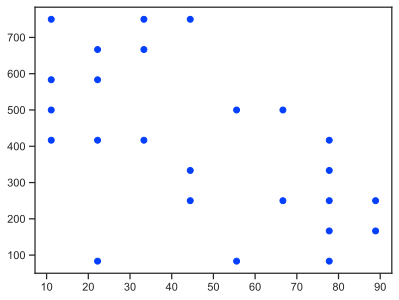

In [ ]:
N = 25
grid = []

x = []; y = []
for j,sdict in enumerate(np.random.choice(balanced,size=N,replace=False)):
    # gather the balanced target and remove the '-balanced' suffix from its name
    balanced_target = sdict['balanced_target']
    balanced_target['name'] = balanced_target['name'].replace('-balanced','')
    grid.append(balanced_target)
    
    # create a Solution object from the balanced target and extract the composition
    sample = Solution(**sdict['balanced_target'])
    x.append(sample.concentration['NaC8'].to('mg/ml').magnitude)
    y.append(sample['HC8'].volume.to('ul').magnitude)
    
    
plt.plot(x,y,ls='None',marker='o')
# plt.gca().set(xlim=(0,0.02),ylim=(-1,1))


# Configure Measurement Campaign

Before starting measurements, configure the Orchestrator with experiment metadata and data handling parameters. This configuration tells the system:
- Where to save measurement data
- How to tag and organize datasets
- Which components to track
- How to structure data for active learning (if enabled)

**Configuration Parameters:**
- `data_tag`: Unique identifier for this experiment (used in filenames and metadata)
- `components`: List of all chemical components in the system
- `AL_components`: Components to use for active learning optimization (can be subset of `components`)
- `next_samples_variable`: Variable name for active learning predictions
- `prepare_volume`: Standard volume to prepare for each sample
- `interactive`: Whether to pause for user confirmation during execution

In [ ]:
orch_client.set_config(
    data_tag='NaC8_grid_v2',
    components=['H2O',"NaC8","HC8"],
    AL_components=['H2O',"NaC8","HC8"], #AL = active learning
    next_samples_variable='next_samples_saxs',
    prepare_volume='1200ul',
    interactive=False,
)
orch_client.enqueue(task_name='validate_config')

'QD-734167c9-034b-45d2-8e2a-3611c9994107'

# Execute Measurement Campaign

This section processes each sample in your grid through the full workflow:
1. **Prepare**: Robot prepares the solution according to the balanced target
2. **Measure**: Sample is measured (e.g., SAXS, UV-Vis, etc.)
3. **Store**: Data is saved with proper tagging and metadata
4. **Process**: Data may be processed or analyzed depending on configuration

**Task Parameters:**
- `task_name='process_sample'`: Executes the full sample processing workflow
- `sample`: The balanced target solution dictionary
- `predict_next=False`: Disable active learning prediction for this batch
- `enqueue_next=False`: Don't automatically queue next samples
- `interactive=False`: Run without pausing for user input

**Note:** For active learning workflows, set `predict_next=True` and `enqueue_next=True` in the final sample or use the active learning section below.

In [ ]:
for sample in grid:
    task = {}
    task['task_name'] = 'process_sample'
    task['sample']  = sample
    task['predict_next'] = False
    task['enqueue_next'] = False
    
    orch_client.enqueue(interactive=False,**task)

# Active Learning Workflow

Active learning enables the AFL system to intelligently select the next samples to measure based on:
- Previous measurement results
- Uncertainty in the model predictions
- Experimental design objectives (e.g., phase boundary detection, optimization)

**How It Works:**
1. The system uses collected data to train a model (e.g., Gaussian Process)
2. The model predicts properties across the composition space
3. Samples are selected where uncertainty is high or where interesting features are predicted
4. New measurements refine the model, improving predictions

**Task Parameters:**
- `task_name='process_sample'`: Same workflow as manual measurements
- `sample`: set to None, assumes that the Agent is primed with data
- `predict_next=True`: Enable active learning prediction
- `enqueue_next=True`: Automatically queue the predicted sample for measurement

**Usage:**
Run this cell repeatedly to iteratively explore the composition space. Each run will:
1. Predict the next most informative sample
2. Queue it for preparation and measurement
3. Update the model with new data
4. Prepare for the next iteration

In [ ]:
task = {}
task['task_name'] = 'process_sample'
task['sample'] = []
task['predict_next'] = True
task['enqueue_next'] = True

orch_client.enqueue(interactive=False,**task)